In [35]:
import mysql.connector
import pandas as pd
import datetime as dt
import pytz
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import entropy
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [36]:
#Connection to  MySQL server, parameters must be filled with correct information otherwise it won't work
conn = mysql.connector.connect(
    host = 'must_be_inserted',
    user = 'must_be_inserted',
    password = 'must_be_inserted',
    database = 'test'
)
cursor = conn.cursor()

# Preparing all addresses

In [37]:
#Extracting addresses with assigned timezone
sql = """SELECT eh.entity, eh.address, sd.timezone, sd.offsset FROM entities_heur as eh
    LEFT JOIN scraped_data as sd ON eh.entity = sd.entity
    LEFT JOIN exchanges_detection as ed on sd.id = ed.id
    WHERE sd.address is not null 
        and sd.location is not null 
        and sd.num_txs > 0 
        and sd.timezone is not null 
        and ed.arkham_entity is null 
        and (ed.arkham_label is null or ed.arkham_label = "Miner");"""
cursor.execute(sql)
data = cursor.fetchall()
len(data)

107739

In [38]:
data = pd.DataFrame(data, columns = ["entity", "address", "timezone", "offset"])
data.head()

,entity,address,timezone,offset
0,Entity 2436,121iyz8ZHtSNHX3mVTHzxztQ33cueBVEu5,Europe/Stockholm,1.0
1,Entity 2436,12418afg3GhCD56oHS5j9f2GzbcbP5oHjY,Europe/Stockholm,1.0
2,Entity 2436,12BmH6NTySEgudTSCYUbPtbn3tLtYyeWYg,Europe/Stockholm,1.0
3,Entity 2436,12DwYSkSw5H6twHcvGDu2tu3ZakdTFShB2,Europe/Stockholm,1.0
4,Entity 2436,12GmdvZKwPpdfRumDakRgJg2rcUG9T3inQ,Europe/Stockholm,1.0


In [39]:
data = data[~data["offset"].isna()]
len(data)

107739

In [40]:
#Transforming address to list and deleting duplicates
addresses = data["address"]
addresses = addresses.drop_duplicates()
addresses = addresses.tolist()
addresses

['121iyz8ZHtSNHX3mVTHzxztQ33cueBVEu5',
 '12418afg3GhCD56oHS5j9f2GzbcbP5oHjY',
 '12BmH6NTySEgudTSCYUbPtbn3tLtYyeWYg',
 '12DwYSkSw5H6twHcvGDu2tu3ZakdTFShB2',
 '12GmdvZKwPpdfRumDakRgJg2rcUG9T3inQ',
 '12HbstJGqroAFPFqXcNrv5rCUyKeFrq8KA',
 '12waCnLnkPYzkLoFH5MdBJ6ezAfHuLaxnB',
 '136mzWZS6nKcGQf8gm34veZ4MPgqh3U2XG',
 '13CbhJdHg8S7dDpPYprrdxjd82Jx7mRbDJ',
 '13h1coaCVdohREBn6w16Ar4tq4xMwu8F8P',
 '13nwi6XyM2tGQisG857WaoZ9z7T6eS3nAK',
 '13VYfxTyTVc7hKBhbu2tasfUaDhY51tGYn',
 '13yrZDdRKkaeto65eAA5rRm5UbwJvquH5i',
 '13yxvLjyBMEzT9npPK2s94B2qxcM1WUyEt',
 '14BkYXxYya3ouMUXzXJak7sRGuo1MHmVM5',
 '14btWNBqPaeXS3SP8zbZiBLQ6SpTdnMhtR',
 '14CtPponx4kPKvFAhSs1L74SWoVve4Qh3m',
 '14iomWwn8ZP3tHTVCFrGw4ifdJQk2xFtTf',
 '14Pdw3wQ1qoptucZjeks9B2w2KHjoFDxAm',
 '14PNSxUAPafdGWa56HrETssfoBVvHYk87P',
 '14qLctyFnJbwZstXkjf8jq7GtyBMXejB3m',
 '14vK6KwiMcwV59F654N3xFkFh44Sang93E',
 '154mQ3WwCVmgLG3dbub83CwBBwacfWMmUC',
 '155gBnpiBQcpnP6coTX6V7znSK3G73uNjK',
 '15abeky6zHJYZb4sqx4PppKrJz61gQTYNe',
 '15R5sJ2GFAQfecPYr7W3uUT

# Getting transaction data

In [41]:
#Getting all outgoing transaction to addresses from list
placeholders = ','.join(['%s'] * len(addresses))

query = f"""SELECT DISTINCT ti.txid, ti.input_order, ti.address, bd.mempool_entry_time, bd.fee, bd.num_inputs, bd.num_outputs, ti.value FROM tx_inputs AS ti
LEFT JOIN blockchain_data AS bd on ti.txid = bd.txid
WHERE address in ({placeholders});"""

cursor.execute(query, addresses)
database = cursor.fetchall()
database = pd.DataFrame(database, columns = ["txid", "input_order", "address", "mempool_entry_time", "fee", "num_inputs", "num_outputs", "value"])
database.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value
0,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 16:31:40,22.831050,2,2,0.002373
1,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,1,18rnnk2vr58dV9dHsxMFbRhyZ8NVFBNo2o,2014-12-20 16:31:40,22.831050,2,2,0.999900
2,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 14:20:49,26.737968,2,2,0.298024
3,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,1,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 14:20:49,26.737968,2,2,0.158314
4,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 22:19:07,34.793774,1,2,0.285407


In [42]:
#Merging transaction data to addresses to obtain entity identification number
db_final = database.merge(
    data,
    how = "left",
    on = "address"
)

In [43]:
#Creating help variable with adjusted time to UTC +0:00
db_final["time_adjusted"] = db_final.apply(
    lambda r: r["mempool_entry_time"] + pd.Timedelta(hours = r["offset"])- pd.Timedelta(hours = 1),
    axis = 1
)
db_final = db_final.drop_duplicates(subset = ["txid"])
db_final.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value,entity,timezone,offset,time_adjusted
0,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 16:31:40,22.831050,2,2,0.002373,Entity 1940,Europe/Kyiv,2.0,2014-12-20 17:31:40
10,00006d4fee0006f2f51b4e6cde3197d9899ec53fafdc98a0ae610ba794ae442c,0,1L56rn8BDX68iZfEJftFGJJHYDN3Gv1UL7,2015-11-26 14:20:49,26.737968,2,2,0.298024,Entity 505,Asia/Manila,8.0,2015-11-26 21:20:49
12,00007bf94d53e5a2cfb4d7aa94039553fadd80f85b9b5eca57de2bd986d56e2e,0,188FPxXv1i4d9F7jQUYUf1Zt2RTh7RnFCG,2016-05-15 22:19:07,34.793774,1,2,0.285407,Entity 70,Europe/Kyiv,2.0,2016-05-15 23:19:07
13,0000a1407c1f573268ea82a20305ed68294351a1f665d08544c3900987df3c43,0,1NissionTGS4S8DvNmGf13amLQuWUZM1nd,2017-08-17 02:59:42,389.105058,1,2,0.107424,Entity 2090,Asia/Tokyo,9.0,2017-08-17 10:59:42
14,0000dec5df278bdb99d2c1763ddbfe93114651e2d87269a1d6ee3065682da921,0,36mskh4wzSgYCXUNae61VF98HrXrjGYdRr,2016-07-27 21:45:25,149.700599,1,2,53.317689,Entity 106,Europe/Stockholm,1.0,2016-07-27 21:45:25


In [44]:
len(db_final)

317843

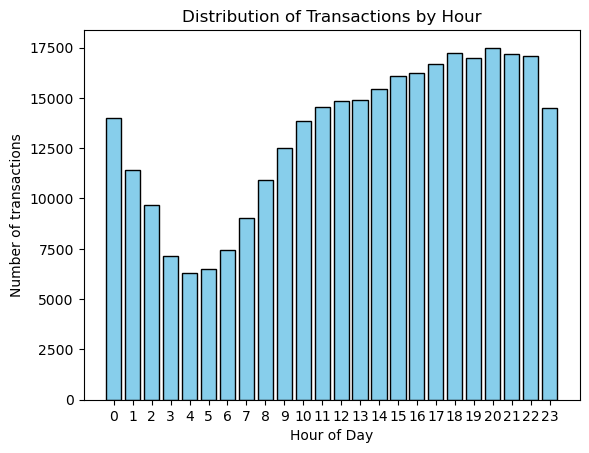

In [45]:
#General  graph of transaction activity tranformed to UTC +0:00
counts, bins, patches = plt.hist(db_final["time_adjusted"].dt.hour, bins=np.arange(25), 
                                 rwidth=0.8, color='skyblue', edgecolor='black')

plt.xticks(np.arange(24) + 0.5, labels=range(24))

plt.title("Distribution of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of transactions")

plt.show()

# Creating regions

In [46]:
#Summary of entities and transactions numbers per each timezone
summary = (
    db_final.groupby("offset")
        .agg(
            num_of_entities=("entity", "nunique"),
            num_of_txs=("txid", "count")
        )
        .reset_index()
)
summary["avg_num_of_txs_per_entity"] = round(summary["num_of_txs"]/summary["num_of_entities"],2)
summary = summary.sort_values("offset")
summary["entities%"] = round(summary["num_of_entities"]/sum(summary["num_of_entities"])*100,2)
summary

,offset,num_of_entities,num_of_txs,avg_num_of_txs_per_entity,entities%
0,-10.00,7,185,26.43,0.15
1,-8.00,152,7458,49.07,3.25
2,-7.00,53,1517,28.62,1.13
3,-6.00,154,5675,36.85,3.29
4,-5.00,654,41696,63.76,13.96
5,-4.00,37,1051,28.41,0.79
6,-3.00,118,7272,61.63,2.52
7,0.00,272,18586,68.33,5.81
8,1.00,749,72266,96.48,15.99
9,2.00,329,29453,89.52,7.02


In [47]:
sum(summary["num_of_entities"])

4684

In [48]:
#Mapping and grouping data by defined regions
region_mapping = {
    # America
    -8.0: 'America', -7.0: 'America', -6.0: 'America', -5.0: 'America', -4.0: 'America', -3.0: 'America',
    
    # Euro-Africa
    0.0: 'Euro_Africa', 1.0: 'Euro_Africa', 2.0: 'Euro_Africa', 3.0: 'Euro_Africa',
    
    # Central Asia / India / Middle East
    3.5: 'Central_Asia', 4.0: 'Central_Asia', 4.5: 'Central_Asia', 5.0: 'Central_Asia', 
    5.5: 'Central_Asia', 5.75: 'Central_Asia', 6.0: 'Central_Asia', 6.5: 'Central_Asia',
    
    # East Asia / Pacific
    7.0: 'East_Asia_Pac', 8.0: 'East_Asia_Pac', 9.0: 'East_Asia_Pac', 10.0: 'East_Asia_Pac', 10.5: 'East_Asia_Pac', 11.0: 'East_Asia_Pac', 
    12.0: 'East_Asia_Pac', 13.0: 'East_Asia_Pac', -10.0: 'East_Asia_Pac', -9.0: 'East_Asia_Pac'
}

db_final['region'] = db_final['offset'].map(region_mapping)

In [49]:
#Summary of entities and transactions numbers per each region
summary = (
    db_final.groupby("region")
        .agg(
            num_of_entities=("entity", "nunique"),
            num_of_txs=("txid", "count")
        )
        .reset_index()
)
summary["avg_num_of_txs_per_entity"] = round(summary["num_of_txs"]/summary["num_of_entities"],2)
summary = summary.sort_values("region")
summary["entities%"] = round(summary["num_of_entities"]/sum(summary["num_of_entities"])*100,2)
summary

,region,num_of_entities,num_of_txs,avg_num_of_txs_per_entity,entities%
0,America,1168,64669,55.37,24.94
1,Central_Asia,849,56867,66.98,18.13
2,East_Asia_Pac,1163,69533,59.79,24.83
3,Euro_Africa,1504,126774,84.29,32.11


# Creating final dataset

In [50]:
#Extracting only hour of transaction from dataset
db_final["hour"] = pd.to_datetime(db_final["mempool_entry_time"]).dt.hour

In [51]:
#Aggregation of transaction into entities
pivot = (
    db_final.pivot_table(
        index=["entity", "region"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)

In [52]:
pivot.head()

,hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
entity,region,,,,,,,,,,,,,,,,,,,,,,,,
Entity 0,Central_Asia,75,129,126,149,90,152,104,192,230,255,114,108,106,173,178,86,104,109,40,90,43,100,131,109
Entity 1,East_Asia_Pac,6,20,65,69,77,45,49,60,58,72,68,68,57,65,45,43,41,35,5,8,9,6,5,7
Entity 10,Euro_Africa,149,125,122,76,60,63,41,36,25,59,46,62,64,70,104,90,131,141,124,135,142,129,155,154
Entity 100,East_Asia_Pac,1,4,6,5,6,16,5,14,12,8,14,7,13,11,11,4,13,15,26,13,5,1,4,1
Entity 1000,Euro_Africa,1,5,5,2,2,0,1,2,0,1,1,3,2,2,1,1,0,0,1,0,0,1,1,0


In [53]:
table = pivot.reset_index()
table.columns.name = None
table.head()

,entity,region,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Entity 0,Central_Asia,75,129,126,149,90,152,104,192,230,255,114,108,106,173,178,86,104,109,40,90,43,100,131,109
1,Entity 1,East_Asia_Pac,6,20,65,69,77,45,49,60,58,72,68,68,57,65,45,43,41,35,5,8,9,6,5,7
2,Entity 10,Euro_Africa,149,125,122,76,60,63,41,36,25,59,46,62,64,70,104,90,131,141,124,135,142,129,155,154
3,Entity 100,East_Asia_Pac,1,4,6,5,6,16,5,14,12,8,14,7,13,11,11,4,13,15,26,13,5,1,4,1
4,Entity 1000,Euro_Africa,1,5,5,2,2,0,1,2,0,1,1,3,2,2,1,1,0,0,1,0,0,1,1,0


In [54]:
cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table["total"] = table[cols_to_sum].sum(axis = 1)
table["log_total"] = table["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table[cols_to_sum] = (table[cols_to_sum] + alpha).div(table["total"] + 24*alpha, axis = 0)

In [55]:
#Finding the middle of the 5 hour minimum inactivity window and the % value of this window
hourly_data = table[cols_to_sum]
circular_data = pd.concat([hourly_data, hourly_data.iloc[:,:4]], axis = 1)
rolling_sums = circular_data.T.rolling(window=5).sum().T
hours = (rolling_sums.iloc[:, 4:].idxmin(axis=1).astype(int) - 2)%24
table["min_5h_activity"] = hours
table["min_5h_activity_sin"] = np.sin(hours*np.pi/12)
table["min_5h_activity_cos"] = np.cos(hours*np.pi/12)
table["min_5h_activity_%"] = rolling_sums.iloc[:, 4:].min(axis=1)

In [56]:
table.head()

,entity,region,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%
0,Entity 0,Central_Asia,0.025191,0.043089,0.042095,0.049718,0.030162,0.050713,0.034803,0.063971,0.076566,0.084853,0.038117,0.036129,0.035466,0.057673,0.059330,0.028837,0.034803,0.036460,0.013590,0.030162,0.014584,0.033477,0.043752,0.036460,2993,8.004032,19,-0.965926,2.588190e-01,0.128273
1,Entity 1,East_Asia_Pac,0.006951,0.020854,0.065541,0.069513,0.077458,0.045680,0.049652,0.060576,0.058590,0.072493,0.068520,0.068520,0.057597,0.065541,0.045680,0.043694,0.041708,0.035750,0.005958,0.008937,0.009930,0.006951,0.005958,0.007944,983,6.890609,22,-0.500000,8.660254e-01,0.037736
2,Entity 10,Euro_Africa,0.064461,0.054147,0.052858,0.033090,0.026214,0.027503,0.018049,0.015900,0.011173,0.025784,0.020198,0.027073,0.027933,0.030511,0.045122,0.039106,0.056725,0.061023,0.053717,0.058444,0.061453,0.055866,0.067039,0.066609,2303,7.741968,8,0.866025,-5.000000e-01,0.091104
3,Entity 100,East_Asia_Pac,0.008368,0.020921,0.029289,0.025105,0.029289,0.071130,0.025105,0.062762,0.054393,0.037657,0.062762,0.033473,0.058577,0.050209,0.050209,0.020921,0.058577,0.066946,0.112971,0.058577,0.025105,0.008368,0.020921,0.008368,215,5.370638,23,-0.258819,9.659258e-01,0.066946
4,Entity 1000,Euro_Africa,0.035714,0.107143,0.107143,0.053571,0.053571,0.017857,0.035714,0.053571,0.017857,0.035714,0.035714,0.071429,0.053571,0.053571,0.035714,0.035714,0.017857,0.017857,0.035714,0.017857,0.017857,0.035714,0.035714,0.017857,32,3.465736,18,-1.000000,-1.836970e-16,0.107143


In [58]:
table.to_csv("database_from_Bitcointalk.csv", index = False)

# Data without labels

In [59]:
#Addresses which dont have timezone but has higher number of transaction than 0
sql = """SELECT eh.entity, eh.address FROM entities_heur as eh
    LEFT JOIN scraped_data as sd ON eh.entity = sd.entity
    LEFT JOIN exchanges_detection as ed on sd.id = ed.id
    WHERE sd.address is not null 
        and sd.location is null 
        and sd.num_txs > 0 
        and sd.timezone is null 
        and ed.arkham_entity is null 
        and (ed.arkham_label is null or ed.arkham_label = "Miner");"""
cursor.execute(sql)
data = cursor.fetchall()
len(data)

309071

In [60]:
data = pd.DataFrame(data, columns = ["entity", "address"])
data.head()

,entity,address
0,Entity 4523,122EWGfg9yYkjjjCRutnTNsfokagtPFMDo
1,Entity 4523,124d6N2ajow1fJ5L8DDrchn6LPLGDmhkiy
2,Entity 4523,124TQXntz7akAYCrUxDjLuVg7fLGTJqcgt
3,Entity 4523,12bmysWpHsvLVxm1RFjDo4qiTopLiiU211
4,Entity 4523,12CdT4DhJ6TYkFKR5sRsPUTjyetspt3X5y


In [61]:
addresses = data["address"]
addresses = addresses.drop_duplicates()
addresses = addresses.tolist()
addresses

['122EWGfg9yYkjjjCRutnTNsfokagtPFMDo',
 '124d6N2ajow1fJ5L8DDrchn6LPLGDmhkiy',
 '124TQXntz7akAYCrUxDjLuVg7fLGTJqcgt',
 '12bmysWpHsvLVxm1RFjDo4qiTopLiiU211',
 '12CdT4DhJ6TYkFKR5sRsPUTjyetspt3X5y',
 '12Cn79UPjeLEBXb6vcP6h38czqubiyoqag',
 '12fhvK6bVxu1KjBFfaeFtH4e6J1JQPDxvs',
 '12fkV7vod7uY98StyfKCLcxcCnFaqeh9hz',
 '12gLVYb9SXUuJo6DW6r7ueCKxDs3ity2X1',
 '12HLVZFFNCajLbBSELvzQAWNjGJnQ4NciL',
 '12j75MZUBJbA1WyyAd6THX1xoL7QgVFPTw',
 '12MLYG6DT4gSXcCwUogr7Eu3F1ZQEHbEmo',
 '12nBhAuVjbf89T7XQZNzCqxgRTA1Jp4K61',
 '12nHoceSUzRcNs4FFRNUurmavFw1tpQsyj',
 '12rmBW4ciHJvSDokkFZQtVuDxLoS1sE7G5',
 '12vYzCjKJ6dAV9DQdZAyGPvaZy6xUcWLWs',
 '12wLq3mB145gGyJZNSZ8z4514rBGWgGYJ6',
 '134EZNDQUFHiDtmXr8vRAgmXrK9R83dWG4',
 '139Jni3bH8aA1vsERGhwD4oX7wLcCdFypc',
 '13AqWyzYeaQX6zQbgfD47o5DGjNi4djoQC',
 '13h6r8sGubtpRFnqifsAq48Z3QaAuPaQM9',
 '13JKwCBGkjNRjFphk9JzCmvZxhmRJKHDjk',
 '13M1sWJPbKwa7s3m9oLUsy8tVRfRTTkuKZ',
 '13MvCB2nRhVnaMeHLMkpC7zk85gPBCRbks',
 '13nuUgSG17Ub7TUpT4P4m9RqrU3LFGdCH6',
 '13p1xLrBJYUwKt5Ko2riNF3

In [62]:
#Getting transactions data
placeholders = ','.join(['%s'] * len(addresses))

query = f"""SELECT DISTINCT ti.txid, ti.input_order, ti.address, bd.mempool_entry_time, bd.fee, bd.num_inputs, bd.num_outputs, ti.value FROM tx_inputs AS ti
LEFT JOIN blockchain_data AS bd on ti.txid = bd.txid
WHERE address in ({placeholders});"""

cursor.execute(query, addresses)
database = cursor.fetchall()
database = pd.DataFrame(database, columns = ["txid", "input_order", "address", "mempool_entry_time", "fee", "num_inputs", "num_outputs", "value"])
database.head()

,txid,input_order,address,mempool_entry_time,fee,num_inputs,num_outputs,value
0,00002b6911acab0646d1e6bb9d2ac3af7cd0a186903511a1e67391654457c572,0,15BJytM7EP2kRNYH17Xs9rikWxzWULeHC4,2014-10-06 23:34:29,38.759690,1,2,0.000664
1,00002b9716495056871d062d4c2b925cdcb142711680b83d85f3cd6dfd842b5e,0,1HKotTFHWqXKTCn2wKyKnFPtVuXgCWVcrw,2015-02-21 13:41:41,38.910506,1,2,0.064700
2,00004236ec2aaae74e77b2343cff51a7362361d08190cd7ad5469dc4ab7f6f82,0,14ja2oRLpidSAaDZEoBwtWnh2HrZChmBp9,2015-10-26 06:01:51,26.809651,2,2,0.204100
3,00004236ec2aaae74e77b2343cff51a7362361d08190cd7ad5469dc4ab7f6f82,1,14ja2oRLpidSAaDZEoBwtWnh2HrZChmBp9,2015-10-26 06:01:51,26.809651,2,2,1.261964
4,00004ca51f952c2f308dc85ddff72cf33e50b1f280cb7af20fccf69d5e857091,0,1R8wSZR6YCDDSDc1m1qSHHh5X5GUab9XX,2014-12-20 16:31:40,22.831050,2,2,0.002373


In [63]:
db_final = database.merge(
    data,
    how = "left",
    on = "address"
)

In [64]:
db_final["hour"] = pd.to_datetime(db_final["mempool_entry_time"]).dt.hour
pivot = (
    db_final.pivot_table(
        index=["entity"],
        columns="hour",
        values="txid",
        aggfunc="count",
        fill_value=0
    )
)
table = pivot.reset_index()
table.columns.name = None
table.head()

,entity,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Entity 10000,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Entity 10001,0,3,2,2,5,9,6,7,5,9,4,11,7,17,10,1,15,26,12,10,1,0,4,1
2,Entity 10002,0,0,0,0,0,2,3,0,0,0,0,0,1,7,6,0,0,1,0,2,0,0,0,0
3,Entity 10003,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Entity 10005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [65]:
cols_to_sum = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
table["total"] = table[cols_to_sum].sum(axis = 1)
table["log_total"] = table["total"].apply(lambda r: np.log(r))

#Bayesian normalization of data 
alpha = 1
table[cols_to_sum] = (table[cols_to_sum] + alpha).div(table["total"] + 24*alpha, axis = 0)

#Finding the middle of the 5 hour minimum inactivity window and the % value of this window
hourly_data = table[cols_to_sum]
circular_data = pd.concat([hourly_data, hourly_data.iloc[:,:4]], axis = 1)
rolling_sums = circular_data.T.rolling(window=5).sum().T
hours = (rolling_sums.iloc[:, 4:].idxmin(axis=1).astype(int) - 2)%24
table["min_5h_activity"] = hours
table["min_5h_activity_sin"] = np.sin(hours*np.pi/12)
table["min_5h_activity_cos"] = np.cos(hours*np.pi/12)
table["min_5h_activity_%"] = rolling_sums.iloc[:, 4:].min(axis=1)

table.head()

,entity,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,total,log_total,min_5h_activity,min_5h_activity_sin,min_5h_activity_cos,min_5h_activity_%
0,Entity 10000,0.028571,0.028571,0.028571,0.028571,0.342857,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,0.028571,11,2.397895,7,0.965926,-0.258819,0.142857
1,Entity 10001,0.005236,0.020942,0.015707,0.015707,0.031414,0.052356,0.036649,0.041885,0.031414,0.052356,0.026178,0.062827,0.041885,0.094241,0.057592,0.010471,0.083770,0.141361,0.068063,0.057592,0.010471,0.005236,0.026178,0.010471,167,5.117994,22,-0.500000,0.866025,0.057592
2,Entity 10002,0.021739,0.021739,0.021739,0.021739,0.021739,0.065217,0.086957,0.021739,0.021739,0.021739,0.021739,0.021739,0.043478,0.173913,0.152174,0.021739,0.021739,0.043478,0.021739,0.065217,0.021739,0.021739,0.021739,0.021739,22,3.091042,2,0.500000,0.866025,0.108696
3,Entity 10003,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.080000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,1,0.000000,2,0.500000,0.866025,0.200000
4,Entity 10005,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.040000,0.080000,0.040000,0.040000,1,0.000000,2,0.500000,0.866025,0.200000


In [66]:
table.to_csv("database_from_Bitcointalk_not_labeled.csv", index = False)

In [67]:
len(table)

16236